In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import pandas as pd
import sys
sys.path.append("/users/ziyzhang/topology-research")
import globals as gl
plt.rcParams.update({'font.size': 22})

In [2]:
def plot_bench_bars(_data: dict, legends: list, title: str, x_label: str, y_label: str, y_log: bool = False, normalized: bool = False, errors: dict = None):

    ## Example usage:
    # plot_data = {
    #     'Benchmark 1': [0.8, 0.7, 0.9],  
    #     'Benchmark 2': [0.6, 0.5, 0.7],  
    #     'Benchmark 3': [0.9, 0.8, 0.7],   
    #     'Benchmark 4': [0.9, 0.8, 0.7]
    # }

    # errors_data = {
    #     'Benchmark 1': [(0.05, 0.1), (0.06, 0.12), (0.03, 0.08)],  
    #     'Benchmark 2': [(0.03, 0.08), (0.04, 0.1), (0.02, 0.06)],  
    #     'Benchmark 3': [(0.04, 0.09), (0.05, 0.11), (0.03, 0.07)],   
    #     'Benchmark 4': [(0.03, 0.08), (0.04, 0.1), (0.02, 0.06)]
    # }

    # legends = ['legend 1', 'legend 2', 'legend 3']
    # plot_bench_bars(plot_data, errors_data, legends, "Performance Comparison", "Benchmark", "Performance", y_log=False, normalized=False)

    # Calculate bar width dynamically based on the number of legends
    num_legends = len(legends)
    bar_width = 0.7 / num_legends  # Adjust this scaling factor as needed

    # Generating x positions for each group of bars
    x_positions = np.arange(len(_data))  

    # Generate colors using a predefined colormap
    colors = cm.tab10(np.linspace(0, 1, num_legends))

    # Plotting
    plt.figure(figsize=(16, 4))  # Adjust size if necessary
    for i, legend in enumerate(legends):
        # Extracting performance metrics for each legend
        performance = [_data[bench][i] for bench in _data]
        if errors:
            error_min_max = np.array([errors[bench][i] for bench in errors])
        # Adjusting x positions for each group of bars
        x_positions_adjusted = x_positions + (i - num_legends//2) * bar_width
        # Plotting bars for each legend
        plt.bar(x_positions_adjusted, performance, width=bar_width, align='center', label=legend, color = colors[i])

        # Adding error bars
        if errors:
            error_bars = error_min_max.swapaxes(0, 1)
            plt.errorbar(x_positions_adjusted[:len(errors)], performance[:len(errors)], 
                        error_bars, fmt='none', ecolor='k', capsize=5)

    # Adding labels and title
    plt.xlabel(x_label)
    plt.ylabel(y_label)
    # if normalized:
    #     plt.ylim(0, 1)
    if y_log:
        plt.yscale("log")  
    plt.title(title)
    plt.xticks(x_positions, _data.keys())
    # Moving the legend outside the figure to the right
    plt.legend(loc='upper center', bbox_to_anchor=(0.5, -0.55), ncol=4)
    plt.ylim(0, 11)

    # Show plot
    plt.show()

In [3]:
df = pd.read_csv("/users/ziyzhang/topology-research/Nexullance_journal_data_gen/MD_Nexullance/DDF/DDF_36_5_MD_IT_uniform_shift_1_halfshift.csv")

In [4]:
df

,V,D,M_name,M_weight,phi_ECMP_ASP,phi_MP_APST4,phi_IT,phi_MD_IT,phi_MD_MP_APST4,phi_MP_APST4_uniform,phi_MP_APST4_shift_1,phi_MP_APST4_halfshift
0,36,5,uniform,0.333333,5.150421,7.178858,5.896843,5.741117,7.063129,7.178858,1.351010,1.353574
1,36,5,shift_1,0.333333,5.000000,10.000000,10.000000,10.000000,10.000000,5.000000,10.000000,3.333333
2,36,5,half_shift,0.333333,1.666667,4.000000,3.350783,3.478258,4.000000,1.366667,0.833333,4.000000


In [5]:
# add a new row in df as the harmonic mean

weights = list(df["M_weight"])

harmonic_means = {}
for col in df.columns:
    if df[col].dtype != 'object':  # Exclude non-numeric columns
        harmonic_means[col] = [gl.cal_MD_obj_func(list(df[col]), weights)]

# Convert the harmonic mean dictionary into a new row and append it to the dataframe
harmonic_means['M_name'] = ['harmonic_mean']
harmonic_means['M_weight'] = [None]  # Keeping M_weight as None since it's not numeric
harmonic_mean_row = pd.DataFrame(harmonic_means)


In [6]:
df = pd.concat([df, harmonic_mean_row], axis=0 ,ignore_index=True)


/tmp/ipykernel_2015521/4275428974.py:1: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  df = pd.concat([df, harmonic_mean_row], axis=0 ,ignore_index=True)


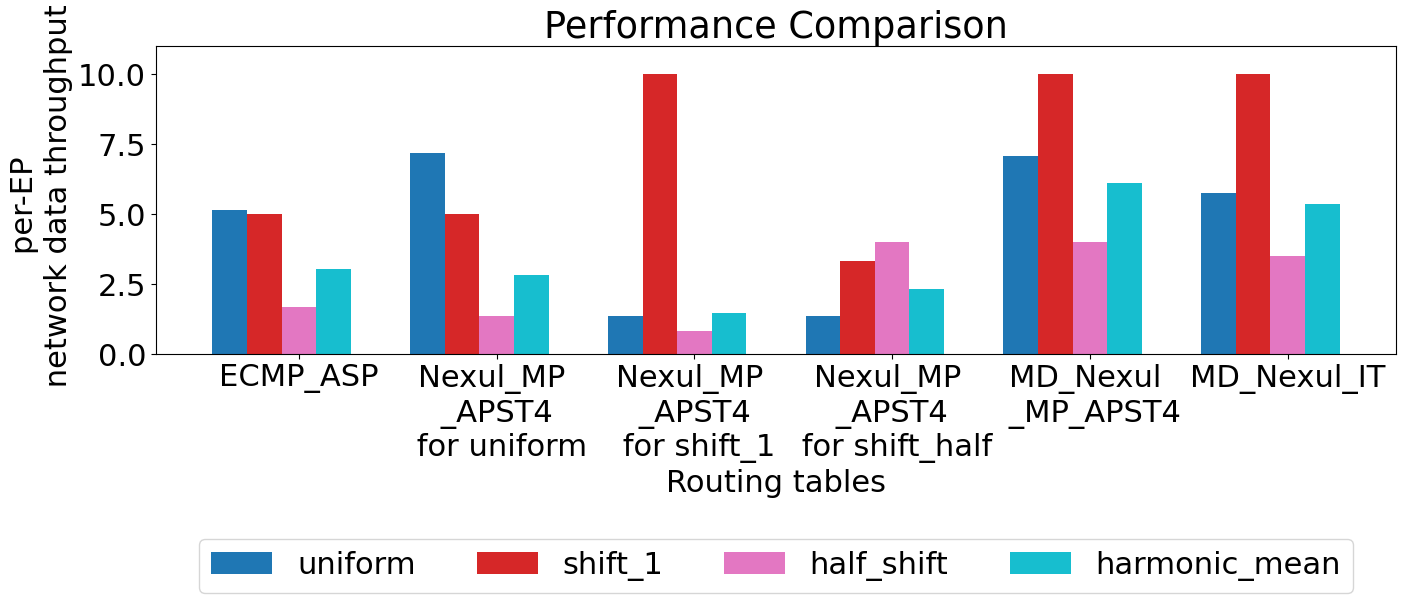

In [7]:
# figure 1: compare matching-Nexullance and MD_Nexullance 
# routing table on the x-axis
plot_data = {
    'ECMP_ASP': list(df["phi_ECMP_ASP"]),  
    'Nexul_MP \n _APST4 \n for uniform': list(df["phi_MP_APST4_uniform"]),  
    'Nexul_MP \n _APST4 \n for shift_1': list(df["phi_MP_APST4_shift_1"]),  
    'Nexul_MP \n _APST4 \n for shift_half': list(df["phi_MP_APST4_halfshift"]),  
    'MD_Nexul \n _MP_APST4': list(df["phi_MD_MP_APST4"]),
    'MD_Nexul_IT': list(df["phi_MD_IT"])
}

legends = list(df["M_name"])
plot_bench_bars(plot_data, legends, "Performance Comparison", "Routing tables", "per-EP \n network data throughput", y_log=False, normalized=False)


In [8]:
df = pd.read_csv("/users/ziyzhang/topology-research/Nexullance_journal_data_gen/MD_Nexullance/DDF/DDF_36_5_MD_IT_uniform_shift_1_halfshift_profiling.csv")

In [9]:
from statistics import mean

df = df[[col for col in df.columns if col.startswith("ave_time_")]]

# add a new row in df as the mean
means = {}
for col in df.columns:
    if df[col].dtype != 'object' and df[col].any():  # Exclude non-numeric columns
        means[col] = mean([ele for ele in df[col] if ele != 0])
# Convert the harmonic mean dictionary into a new row and append it to the dataframe
means['M_name'] = ['mean']
means['M_weight'] = [None]  # Keeping M_weight as None since it's not numeric
new_means_row = pd.DataFrame(means)
# add a new row in df as the sum
sums = {}
for col in df.columns:
    if df[col].dtype != 'object':  # Exclude non-numeric columns
        sums[col] = sum(list(df[col]))
# Convert the harmonic mean dictionary into a new row and append it to the dataframe
sums['M_name'] = ['sum']
sums['M_weight'] = [None]  # Keeping M_weight as None since it's not numeric
new_sums_row = pd.DataFrame(sums)

df = pd.concat([df, new_means_row, new_sums_row], axis=0 ,ignore_index=True)

In [16]:
df

,ave_time_MP_APST4,ave_time_IT,ave_time_MD_MP_APST4,ave_time_MD_IT,M_name,M_weight
0,0.500507,0.117266,0.000000,0.000000,NaN,NaN
1,0.385664,0.003984,0.000000,0.000000,NaN,NaN
2,0.380958,0.020379,0.000000,0.000000,NaN,NaN
3,0.000000,0.000000,67.340095,0.168258,NaN,NaN
4,0.422376,0.047210,67.340095,0.168258,mean,None
5,1.267129,0.141629,67.340095,0.168258,sum,None


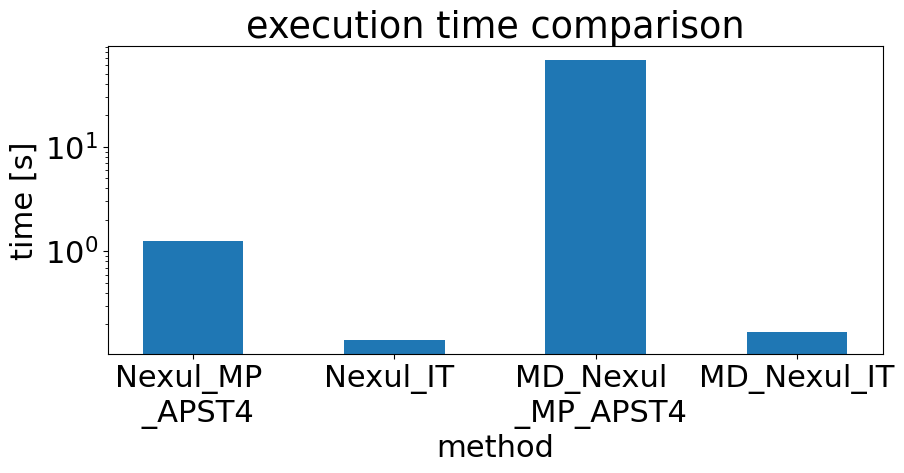

In [23]:
# Sum time
_data = {
    'Nexul_MP \n _APST4': list(df["ave_time_MP_APST4"])[-1],  
    'Nexul_IT \n': list(df["ave_time_IT"])[-1],  
    'MD_Nexul \n _MP_APST4': list(df["ave_time_MD_MP_APST4"])[-1],
    'MD_Nexul_IT': list(df["ave_time_MD_IT"])[-1]
}

# Generating x positions for each group of bars
x_positions = np.arange(len(_data))  

# Plotting
plt.figure(figsize=(10, 4))  # Adjust size if necessary
# Extracting performance metrics for each legend
performance = [_data[bench] for bench in _data]
# Plotting bars for each legend
plt.bar(x_positions, performance, width=0.5, align='center', label=legend)

# Adding labels and title
plt.xlabel("method")
plt.ylabel("time [s]") 
plt.yscale('log')
plt.title("execution time comparison")
plt.xticks(x_positions, _data.keys())

# Show plot
plt.show()

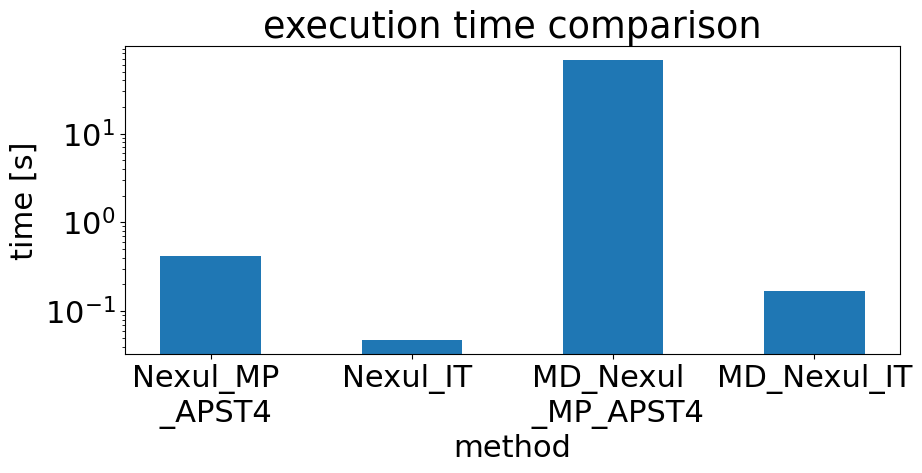

In [24]:
# Mean time
_data = {
    'Nexul_MP \n _APST4': list(df["ave_time_MP_APST4"])[-2],  
    'Nexul_IT \n': list(df["ave_time_IT"])[-2],  
    'MD_Nexul \n _MP_APST4': list(df["ave_time_MD_MP_APST4"])[-2],
    'MD_Nexul_IT': list(df["ave_time_MD_IT"])[-2]
}

# Generating x positions for each group of bars
x_positions = np.arange(len(_data))  

# Plotting
plt.figure(figsize=(10, 4))  # Adjust size if necessary
# Extracting performance metrics for each legend
performance = [_data[bench] for bench in _data]
# Plotting bars for each legend
plt.bar(x_positions, performance, width=0.5, align='center', label=legend)

# Adding labels and title
plt.xlabel("method")
plt.ylabel("time [s]") 
plt.yscale('log')
plt.title("execution time comparison")
plt.xticks(x_positions, _data.keys())

# Show plot
plt.show()